In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
cd /content/drive/MyDrive/42174

/content/drive/MyDrive/42174


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [9]:
data = pd.read_csv('domain_properties.csv')

In [10]:
# show
print(data.head())

    price date_sold         suburb  num_bath  num_bed  num_parking  \
0  530000   13/1/16      Kincumber         4        4            2   
1  525000   13/1/16     Halekulani         2        4            2   
2  480000   13/1/16  Chittaway Bay         2        4            2   
3  452000   13/1/16        Leumeah         1        3            1   
4  365500   13/1/16    North Avoca         0        0            0   

   property_size         type  suburb_population  suburb_median_income  \
0           1351        House               7093                 29432   
1            594        House               2538                 24752   
2            468        House               2028                 31668   
3            344        House               9835                 32292   
4           1850  Vacant land               2200                 45084   

   suburb_sqkm  suburb_lat  suburb_lng  suburb_elevation  cash_rate  \
0        9.914   -33.47252   151.40208                24       

In [11]:
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11160 entries, 0 to 11159
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     11160 non-null  int64  
 1   date_sold                 11160 non-null  object 
 2   suburb                    11160 non-null  object 
 3   num_bath                  11160 non-null  int64  
 4   num_bed                   11160 non-null  int64  
 5   num_parking               11160 non-null  int64  
 6   property_size             11160 non-null  int64  
 7   type                      11160 non-null  object 
 8   suburb_population         11160 non-null  int64  
 9   suburb_median_income      11160 non-null  int64  
 10  suburb_sqkm               11160 non-null  float64
 11  suburb_lat                11160 non-null  float64
 12  suburb_lng                11160 non-null  float64
 13  suburb_elevation          11160 non-null  int64  
 14  cash_r

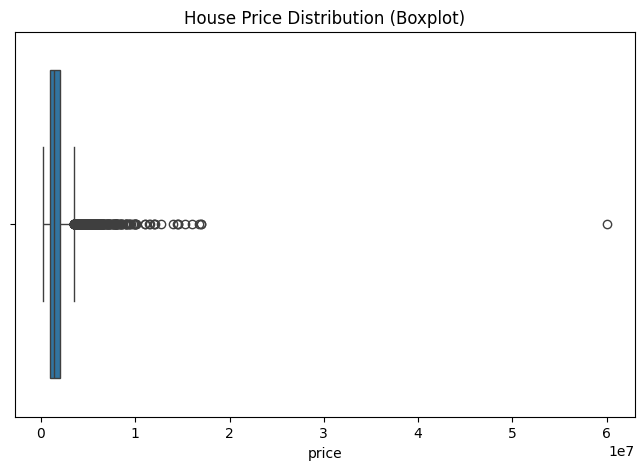

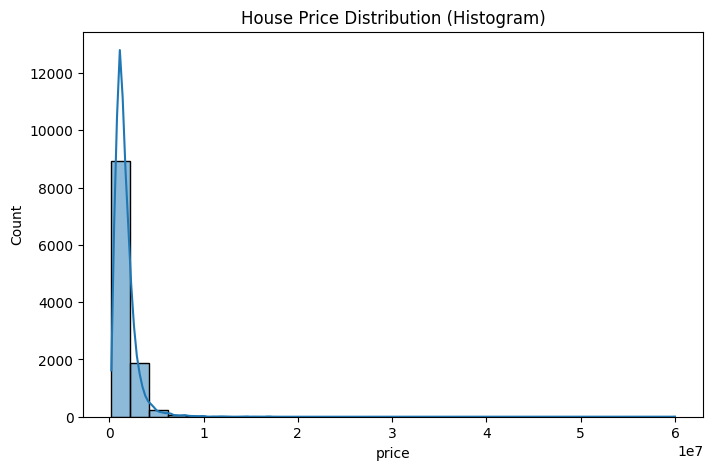

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=data['price'])
plt.title("House Price Distribution (Boxplot)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data['price'], bins=30, kde=True)
plt.title("House Price Distribution (Histogram)")
plt.show()

In [13]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data_clean = data[(data['price'] >= lower) & (data['price'] <= upper)]

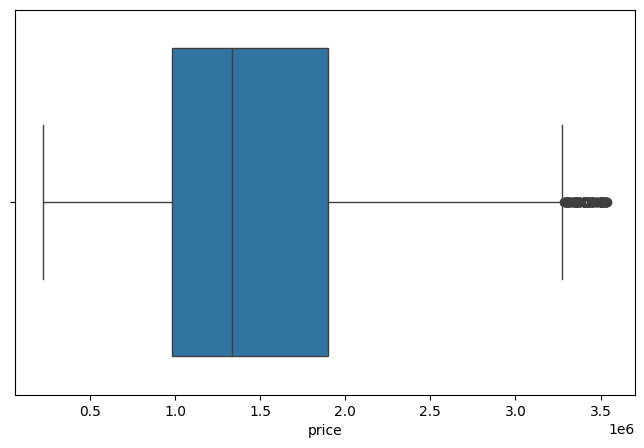

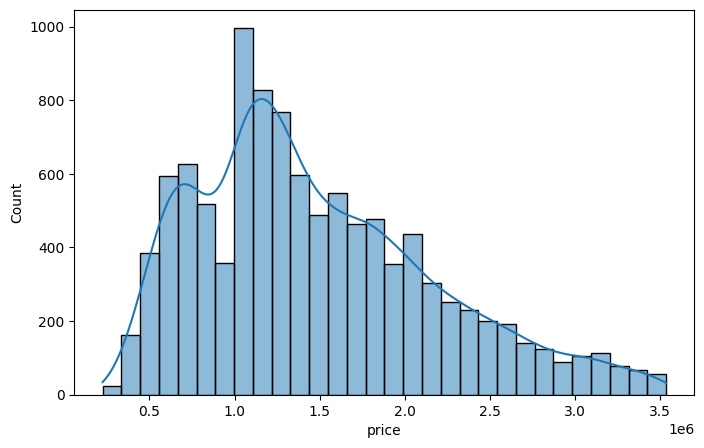

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=data_clean['price'])
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data_clean['price'], bins=30, kde=True)
plt.show()


Form the training dataset, test dataset and futureSample set
Create the training and test datasets

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Target variable
y = data_clean['price']

# Input features
X = data_clean.drop('price', axis=1).copy()

# Convert date_sold into datetime
X['date_sold'] = pd.to_datetime(X['date_sold'], dayfirst=True, errors='coerce')

# Extract year and month
X['sold_year'] = X['date_sold'].dt.year
X['sold_month'] = X['date_sold'].dt.month

# Drop original date_sold
X = X.drop('date_sold', axis=1)

# One-hot encoding for categorical variables
X = pd.get_dummies(X, columns=['suburb', 'type'], drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13126154
)

# Extract future samples
futureSample_X = X_test.tail(2).copy()
futureSample_y = y_test.tail(2).copy()

X_test = X_test.iloc[:-2].copy()
y_test = y_test.iloc[:-2].copy()

# Output dataset size
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Future Sample:", futureSample_X.shape)

# Standardisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
futureSample_X_scaled = scaler.transform(futureSample_X)

/tmp/ipykernel_683/286553260.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['date_sold'] = pd.to_datetime(X['date_sold'], dayfirst=True, errors='coerce')


Training set: (8462, 663)
Test set: (2114, 663)
Future Sample: (2, 663)


The correlation analysis shows that property inflation index, suburb median income, number of bathrooms, and sold year have the strongest positive relationships with housing prices. This suggests that macroeconomic factors, socioeconomic status of suburbs, and property characteristics all influence property values. The relatively moderate correlations indicate that house prices are influenced by multiple interacting factors rather than a single dominant variable.

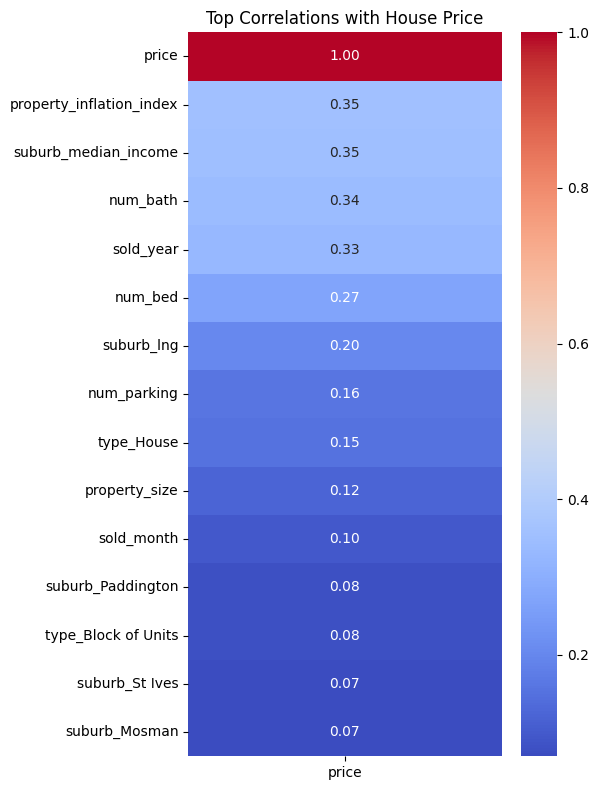

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Copy training data
X_corr = X_train.copy()

# Add target variable
X_corr['price'] = y_train

# Correlation matrix
corr = X_corr.corr(numeric_only=True)

# Get correlations with price
price_corr = corr['price'].sort_values(ascending=False)

# Select top 15 strongest correlations (excluding price itself if needed)
top_corr = price_corr.head(15)

# Convert to DataFrame for heatmap
top_corr_df = top_corr.to_frame()

plt.figure(figsize=(6,8))
sns.heatmap(top_corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Correlations with House Price")
plt.tight_layout()
plt.show()

Train the regressor using the selected learning algorithm
model_option:

*linear regression,

*decision tree

*Random forest

In [22]:
# ===============================
# Model Training and Evaluation
# ===============================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Safe MAPE function
def MAPE(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # avoid division by zero
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Evaluation function
def evaluate(model_name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    r2 = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae = mean_absolute_error(yte, pred)
    mape = MAPE(yte, pred)

    print(f"{model_name:20s} | R2 = {r2:.3f} | RMSE = {rmse:.2f} | MAE = {mae:.2f} | MAPE = {mape:.2f}%")

    return model, {
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

# -------------------------------
# 1) Linear Regression
# -------------------------------
lr_model, lr_scores = evaluate(
    "Linear Regression",
    LinearRegression(),
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

# -------------------------------
# 2) Decision Tree
# -------------------------------
dt_model, dt_scores = evaluate(
    "Decision Tree",
    DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=13126154
    ),
    X_train, y_train,
    X_test, y_test
)

# -------------------------------
# 3) Random Forest
# -------------------------------
rf_model, rf_scores = evaluate(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=3,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=13126154
    ),
    X_train, y_train,
    X_test, y_test
)

# -------------------------------
# Results Summary Table
# -------------------------------
results_df = pd.DataFrame([lr_scores, dt_scores, rf_scores])
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nModel Comparison:")
display(results_df)

Linear Regression    | R2 = 0.658 | RMSE = 411153.36 | MAE = 272988.03 | MAPE = 19.58%
Decision Tree        | R2 = 0.613 | RMSE = 436925.75 | MAE = 295670.52 | MAPE = 19.79%
Random Forest        | R2 = 0.631 | RMSE = 426962.97 | MAE = 311462.72 | MAPE = 23.56%

Model Comparison:


,Model,R2,RMSE,MAE,MAPE
0,Linear Regression,0.657589,411153.359112,272988.029171,19.583807
1,Random Forest,0.630751,426962.968146,311462.723326,23.563222
2,Decision Tree,0.613317,436925.748132,295670.515178,19.792780


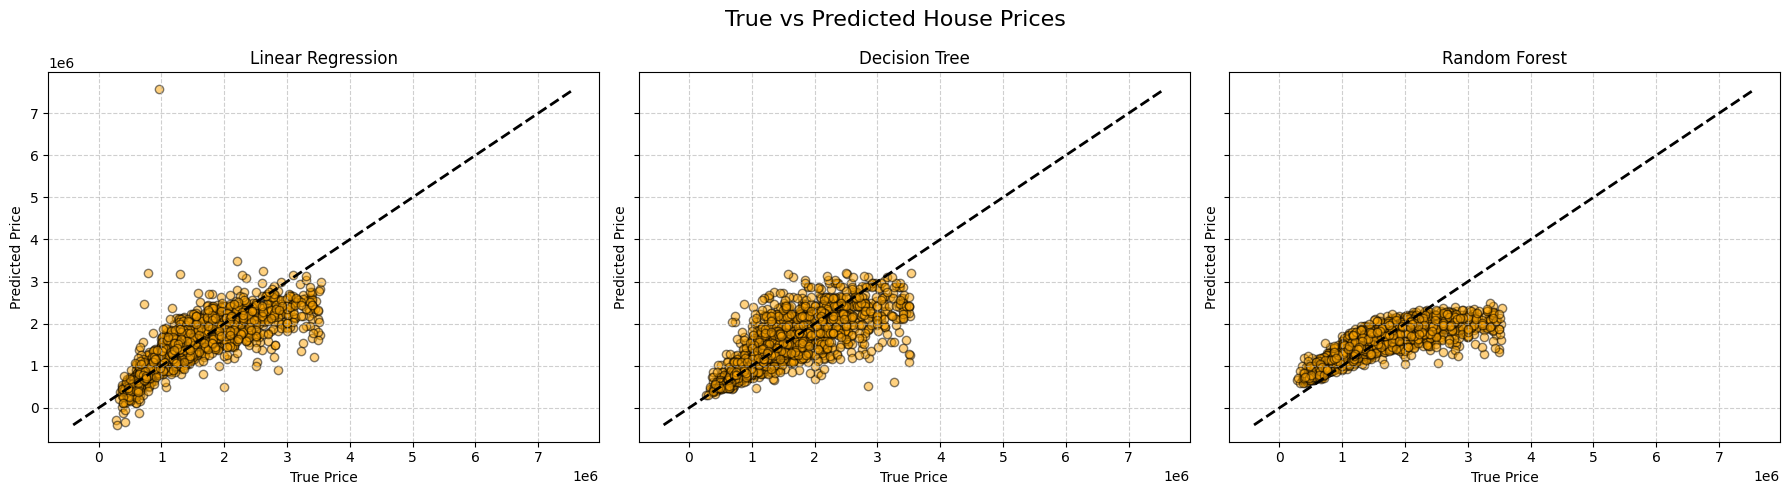

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions
preds = {
    "Linear Regression": lr_model.predict(X_test_scaled),
    "Decision Tree": dt_model.predict(X_test),
    "Random Forest": rf_model.predict(X_test)
}

# Determine global min/max for consistent axes
all_preds = np.concatenate(list(preds.values()))
lo = min(y_test.min(), all_preds.min())
hi = max(y_test.max(), all_preds.max())

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, (name, y_pred) in zip(axes, preds.items()):

    ax.scatter(y_test, y_pred, alpha=0.5, color="orange", edgecolor="k")

    # Perfect prediction line
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=2)

    ax.set_title(name)
    ax.set_xlabel("True Price")
    ax.set_ylabel("Predicted Price")

    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("True vs Predicted House Prices", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# Three models
models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

# Iterate through each model
for name, model in models.items():
    print(f"\n=== {name} ===")

    # Use the correct data for prediction (scaled for Linear Regression, unscaled for others)
    if name == "Linear Regression":
        y_pred_future = model.predict(futureSample_X_scaled)
    else:
        # Use the original unscaled futureSample_X DataFrame
        y_pred_future = model.predict(futureSample_X)


    # Iterate through samples and compare predicted and actual values
    # Use iloc to access rows by integer position
    for i in range(len(futureSample_X)):
        # Access the i-th row of futureSample_X and the i-th value of futureSample_y
        future_sample_row = futureSample_X.iloc[i]
        actual_value = futureSample_y.iloc[i]
        predicted_value = y_pred_future[i]

        error = predicted_value - actual_value  # Calculate error
        print(
    f"For the {i} future data (row index: {future_sample_row.name}), "
    f"the predicted value is {int(predicted_value)}, "
    f"the actual value is {int(actual_value)}, "
    f"error = {int(error)}"
)



=== Linear Regression ===
For the 0 future data (row index: 7626), the predicted value is 1473601, the actual value is 1030000, error = 443601
For the 1 future data (row index: 1959), the predicted value is 1473535, the actual value is 2250000, error = -776464

=== Decision Tree ===
For the 0 future data (row index: 7626), the predicted value is 1353385, the actual value is 1030000, error = 323385
For the 1 future data (row index: 1959), the predicted value is 1283545, the actual value is 2250000, error = -966454

=== Random Forest ===
For the 0 future data (row index: 7626), the predicted value is 1328873, the actual value is 1030000, error = 298873
For the 1 future data (row index: 1959), the predicted value is 1498535, the actual value is 2250000, error = -751464
